# 第7章：Titanicデータ分析を順に試す

2026年9月5日の比較版原稿に対応する学習用ノートブックです。
本文のPythonコード6本を順に収め、最後に確認用セルを加えています。
AIの回答記録を新たに作ったものではありません。

## 目的

欠損値の確認、グループ別の可視化、分類モデルの評価を通じて、結果を自分で読む練習をします。
処理を選ぶ理由と結果の解釈は、書籍の第7章と合わせて確認してください。

## 準備

KaggleのTitanicトレーニングデータ `train.csv` を使います（891行、12列）。
入手元：https://www.kaggle.com/c/titanic
配布元の利用条件を確認して取得してください。データ本体はこの教材では再配布していません。
Google Colabでこのノートブックを開く場合は、ファイル一覧から `train.csv` をアップロードします。
手元のJupyterで使う場合は、ノートブックと同じフォルダに置きます。
必要なライブラリはpandas、matplotlib、scikit-learnです。環境構築には同梱の `requirements.txt` を使えます。

### この教材の前提

訓練712件と評価179件へ分割し、補完値は訓練データだけから求めます。
`random_state=42`、`stratify=y` を指定します。
`Pclass` は簡略化のため数値として扱います。
この分析は関連を見る練習であり、生存の原因を特定するものではありません。


## 実行環境を記録する

ライブラリの版やデータが違うと結果も変わることがあります。まず版とデータの指紋（SHA-256）を記録します。

In [1]:
import sys
import hashlib
from pathlib import Path
import pandas as pd
import matplotlib
import sklearn

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("train.csv SHA-256:", hashlib.sha256(Path("train.csv").read_bytes()).hexdigest())

Python: 3.12.14
pandas: 3.0.5
matplotlib: 3.11.1
scikit-learn: 1.9.0
train.csv SHA-256: 4a437fde05fe5264e1701a7387ac6fb75393772ba38bb2c9c566405af5af4bd7


## 手順

### 1. データの意味を確かめる

行数、列数、先頭の行、列の型、要約統計量を確認します。先頭行の個票を含むこのセルの保存済み出力は、再配布を避けるため掲載していません。自分の環境で実行して確認してください。

In [2]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)      # 行数と列数
print(df.head())     # 先頭5行
df.info()            # 列ごとの型と欠損の有無
df.describe()        # 数値列の要約統計量

### 2. 欠損件数と割合を見る

件数だけで判断せず、欠損の理由や偏りを考えます。本文の処理方針は例であり、他のデータに一律には適用しません。

In [3]:
missing_count = df.isnull().sum()
missing_rate = (df.isnull().sum() / len(df) * 100).round(1)

pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate(%)": missing_rate
})

,missing_count,missing_rate(%)
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,177,19.9
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0


### 3. 生存率と比較の基準を確かめる

生存を1、死亡を0としているため、平均値を生存率として読めます。全員を死亡と予測した場合の正解率も考えてください。

In [4]:
print(df["Survived"].value_counts())
print(df["Survived"].mean())

Survived
0    549
1    342
Name: count, dtype: int64
0.3838383838383838


### 4. グループ別に可視化する

棒グラフの高さから関連を読みます。乗船港の差を、そのまま因果関係として解釈しないことが大切です。掲載用に整えた図は `gen_figures.py` で生成できます。

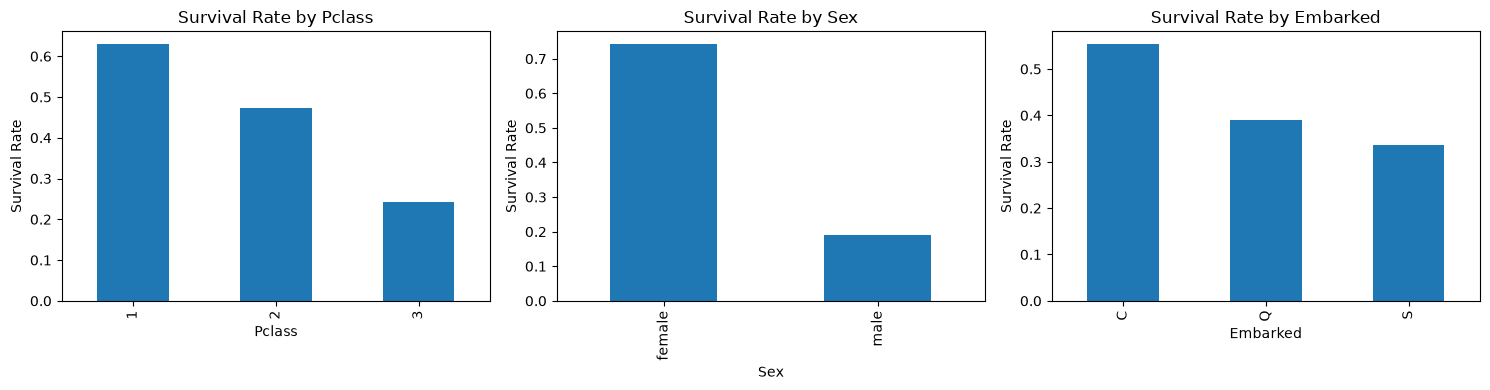

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Pclass", "Sex", "Embarked"]):
    df.groupby(col)["Survived"].mean().plot(kind="bar", ax=ax)
    ax.set_title(f"Survival Rate by {col}")
    ax.set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

### 5. 分割してから補完する

評価データの情報が補完値を通じて訓練に混ざらないよう、先に分割します。補完に使った値と説明変数の列を、後の確認セルでも点検します。

In [6]:
from sklearn.model_selection import train_test_split

df_work = df.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"])
df_work["Sex"] = df_work["Sex"].map({"male": 0, "female": 1})

X = df_work.drop("Survived", axis=1)
y = df_work["Survived"]

# 欠損値を埋める前に分割する
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 補完に使う値は訓練データだけから決める
age_median = X_train["Age"].median()
embarked_mode = X_train["Embarked"].mode()[0]
fill = {"Age": age_median, "Embarked": embarked_mode}
X_train = X_train.fillna(fill)
X_test = X_test.fillna(fill)

# カテゴリ変数の数値化
X_train = pd.get_dummies(X_train, columns=["Embarked"],
                         drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=["Embarked"],
                        drop_first=True, dtype=int)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### 6. モデルを作り、評価する

ロジスティック回帰を使います。正解率だけでなく、混同行列でどちらの誤りが多いかを確かめます。

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print(accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

0.8044692737430168
[[98 12]
 [23 46]]


## 確認

ここからは教材用に追加したセルです。件数、分割、本文の主要な結果を照合します。assertで止まったら数値を合わせるためにコードを変えず、データと実行環境を確認してください。

In [8]:
import numpy as np

assert df.shape == (891, 12)
assert df["PassengerId"].is_unique
assert int(df["Survived"].sum()) == 342
assert df[["Age", "Cabin", "Embarked"]].isnull().sum().tolist() == [177, 687, 2]
assert len(X_train) == 712 and len(X_test) == 179
assert X_train.index.intersection(X_test.index).empty
assert X_train.columns.tolist() == X_test.columns.tolist()
assert X_train.shape[1] == 8
assert not X_train.isnull().any().any()
assert not X_test.isnull().any().any()
assert age_median == df.loc[X_train.index, "Age"].median()
assert embarked_mode == df.loc[X_train.index, "Embarked"].mode()[0]

cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
assert cm.sum() == len(y_test)
assert np.array_equal(cm, [[98, 12], [23, 46]])
assert round(accuracy_score(y_test, pred), 3) == 0.804
assert round(tp / (tp + fn), 3) == 0.667

print("照合を通過しました。")
print("生存率:", round(df["Survived"].mean() * 100, 1), "%")
print("全員死亡と予測した場合:", round((1 - df["Survived"].mean()) * 100, 1), "%")
print("補完値:", fill)
print("説明変数:", X_train.columns.tolist())
print("混同行列:", cm.tolist())
print("生存者の再現率:", round(tp / (tp + fn), 3))
print("係数:")
for name, value in zip(X_train.columns, model.coef_[0]):
    print(f"  {name}: {value:+.3f}")

照合を通過しました。
生存率: 38.4 %
全員死亡と予測した場合: 61.6 %
補完値: {'Age': np.float64(28.5), 'Embarked': 'S'}
説明変数: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
混同行列: [[98, 12], [23, 46]]
生存者の再現率: 0.667
係数:
  Pclass: -1.093
  Sex: +2.558
  Age: -0.039
  SibSp: -0.245
  Parch: -0.072
  Fare: +0.002
  Embarked_Q: +0.286
  Embarked_S: -0.384


## 自分の研究で使うとき

どちらの誤りが問題になるか、変数が予測の時点で手に入るかを考えてください。
同じ前処理をそのまま適用せず、欠損の意味や測定条件を確かめます。
AIが示した解釈を採用する際は、どの表や数値を根拠にしたかを記録します。

変更後は実行環境を再起動し、先頭から再実行して、古い変数や出力が残っていないか確認してください。
